In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

C_GREEN  = '#1D9E75'
C_AMBER  = '#EF9F27'
C_CORAL  = '#D85A30'
C_BLUE   = '#378ADD'
C_PURPLE = '#7F77DD'

# Load master data
master = pd.read_csv("data/master_raw.csv",
                      index_col='date', parse_dates=True)
master = master.ffill()

# Load forecasts
arima_fc   = pd.read_csv("data/forecast_arima.csv",
                          parse_dates=['date']).set_index('date')
prophet_fc = pd.read_csv("data/forecast_prophet.csv",
                          parse_dates=['ds']).set_index('ds')
prophet_fc.index.name = 'date'
lstm_fc    = pd.read_csv("data/forecast_lstm.csv",
                          parse_dates=['date']).set_index('date')

# Actual test period
test = master['brent_price']['2025-09-27':]

# Align on common dates
common = test.index.intersection(prophet_fc.index)
actual   = test.loc[common].values
arima    = arima_fc.loc[common, 'forecast'].values
prophet  = prophet_fc.loc[common, 'yhat'].values
lstm     = lstm_fc.loc[common, 'forecast'].values

print(f"Evaluation period: {common.min().date()} → {common.max().date()}")
print(f"Total trading days evaluated: {len(common)}")

Evaluation period: 2025-09-29 → 2026-03-18
Total trading days evaluated: 118


In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

def rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

models = {
    'ARIMA'  : arima,
    'Prophet': prophet,
    'LSTM'   : lstm
}

results = {}
for name, preds in models.items():
    results[name] = {
        'MAE'  : round(mean_absolute_error(actual, preds), 4),
        'RMSE' : round(rmse(actual, preds), 4),
        'MAPE' : round(mape(actual, preds), 4)
    }

results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'

print("=" * 50)
print("  MODEL EVALUATION RESULTS")
print("=" * 50)
print(results_df.to_string())
print("=" * 50)

best_mae  = results_df['MAE'].idxmin()
best_rmse = results_df['RMSE'].idxmin()
best_mape = results_df['MAPE'].idxmin()

print(f"\nBest MAE  : {best_mae}")
print(f"Best RMSE : {best_rmse}")
print(f"Best MAPE : {best_mape}")

  MODEL EVALUATION RESULTS
            MAE     RMSE     MAPE
Model                            
ARIMA    7.4264  10.1788  10.3513
Prophet  5.4307  10.6462   6.7207
LSTM     1.7980   2.7064   2.4713

Best MAE  : LSTM
Best RMSE : LSTM
Best MAPE : LSTM


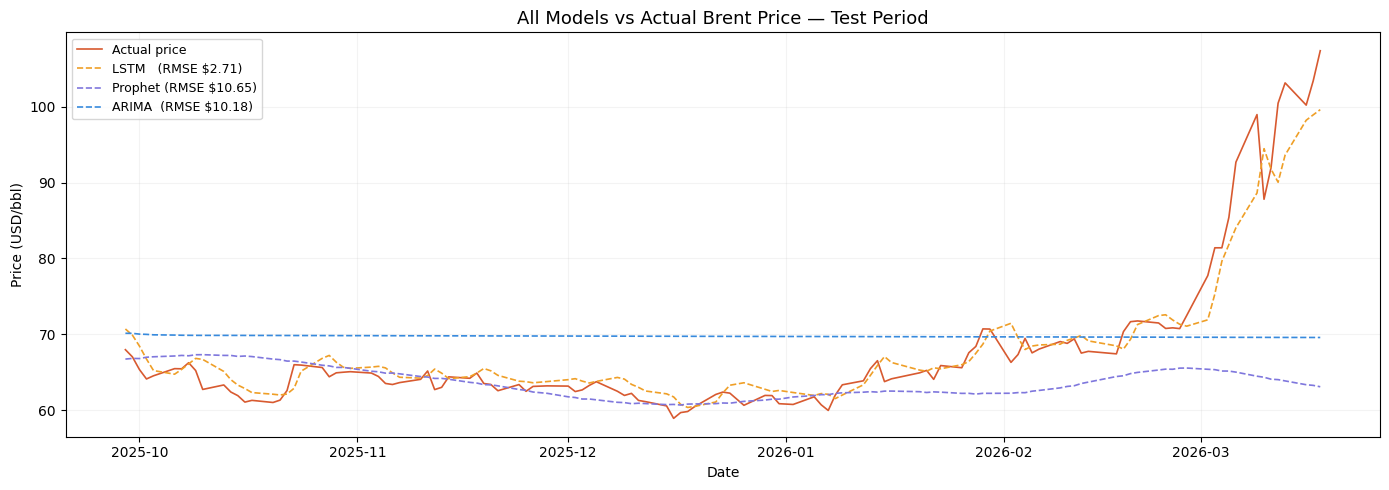

Chart 8 saved.


In [3]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(common, actual,  color=C_CORAL,  linewidth=1.2, label='Actual price')
ax.plot(common, lstm,    color=C_AMBER,  linewidth=1.2, linestyle='--', label=f'LSTM   (RMSE ${results["LSTM"]["RMSE"]:.2f})')
ax.plot(common, prophet, color=C_PURPLE, linewidth=1.2, linestyle='--', label=f'Prophet (RMSE ${results["Prophet"]["RMSE"]:.2f})')
ax.plot(common, arima,   color=C_BLUE,   linewidth=1.2, linestyle='--', label=f'ARIMA  (RMSE ${results["ARIMA"]["RMSE"]:.2f})')

ax.set_title('All Models vs Actual Brent Price — Test Period', fontsize=13)
ax.set_ylabel('Price (USD/bbl)')
ax.set_xlabel('Date')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig('data/chart8_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved.")

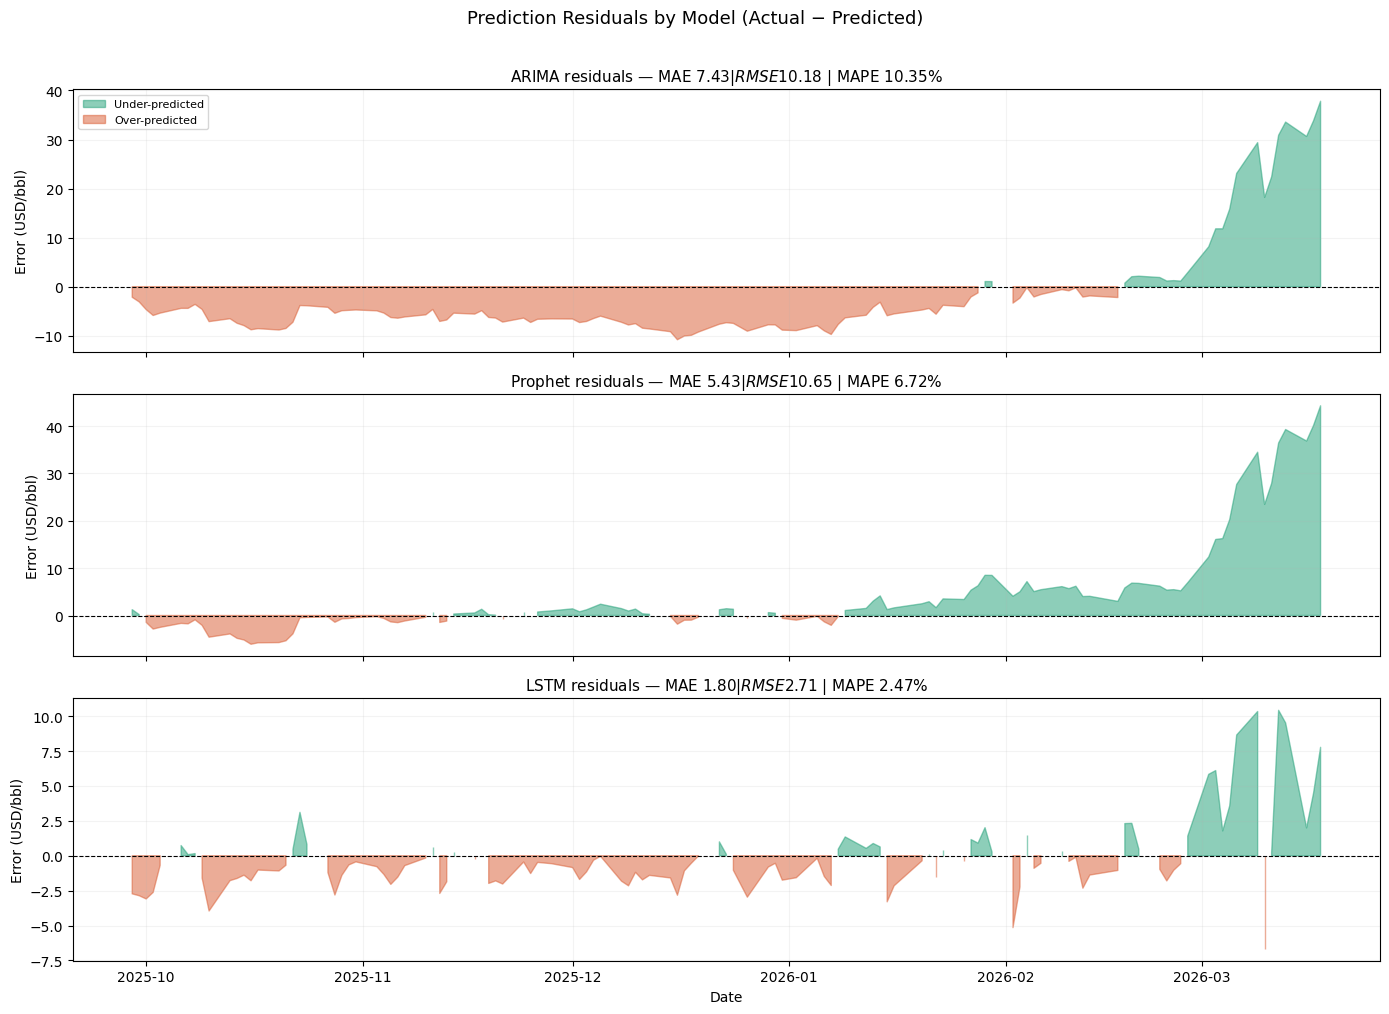

Chart 9 saved.


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

model_data = [
    ('ARIMA',   arima,   C_BLUE,   axes[0]),
    ('Prophet', prophet, C_PURPLE, axes[1]),
    ('LSTM',    lstm,    C_AMBER,  axes[2]),
]

for name, preds, color, ax in model_data:
    residuals = actual - preds
    ax.fill_between(common, residuals,
                    where=residuals >= 0,
                    color=C_GREEN, alpha=0.5, label='Under-predicted')
    ax.fill_between(common, residuals,
                    where=residuals < 0,
                    color=C_CORAL, alpha=0.5, label='Over-predicted')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel('Error (USD/bbl)')
    ax.set_title(f'{name} residuals — MAE ${results[name]["MAE"]:.2f} | RMSE ${results[name]["RMSE"]:.2f} | MAPE {results[name]["MAPE"]:.2f}%', fontsize=11)
    ax.grid(True, alpha=0.15)
    if name == 'ARIMA':
        ax.legend(fontsize=8, loc='upper left')

axes[-1].set_xlabel('Date')
plt.suptitle('Prediction Residuals by Model (Actual − Predicted)', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('data/chart9_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 9 saved.")

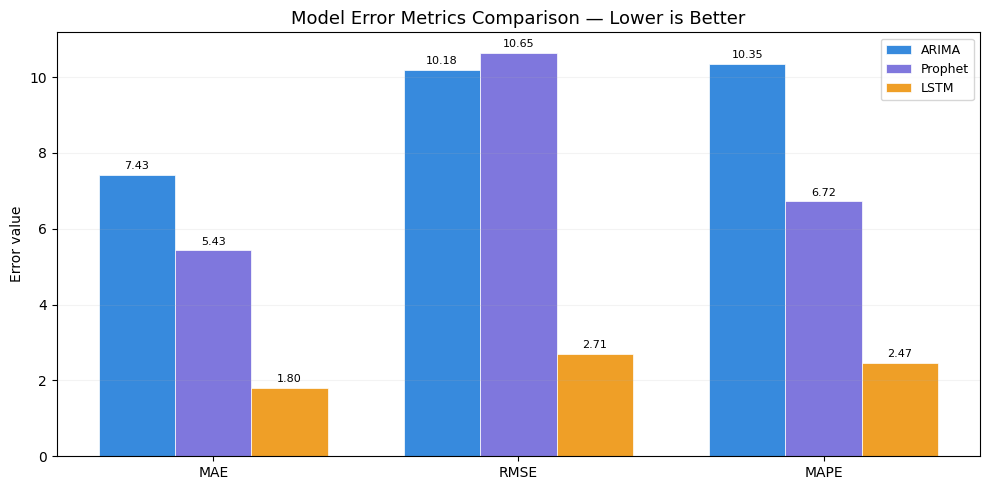

Chart 10 saved.


In [5]:
metrics = ['MAE', 'RMSE', 'MAPE']
model_names = list(results.keys())
colors = [C_BLUE, C_PURPLE, C_AMBER]
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, 
                  label=name, color=color, 
                  edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', 
                va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel('Error value')
ax.set_title('Model Error Metrics Comparison — Lower is Better', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.savefig('data/chart10_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 10 saved.")

In [6]:
lstm_vs_arima  = results['ARIMA']['RMSE']  / results['LSTM']['RMSE']
lstm_vs_prophet = results['Prophet']['RMSE'] / results['LSTM']['RMSE']

print("=" * 60)
print("  EVALUATION SUMMARY")
print("=" * 60)

print(f"""
LSTM Performance:
  MAE  = {results['LSTM']['MAE']:.2f} USD/bbl
  RMSE = {results['LSTM']['RMSE']:.2f} USD/bbl  
  MAPE = {results['LSTM']['MAPE']:.2f}%

LSTM is {lstm_vs_arima:.1f}x better than ARIMA by RMSE
LSTM is {lstm_vs_prophet:.1f}x better than Prophet by RMSE

Key observations:
1. ARIMA (0,1,1) defaulted to near-flat forecast at ~$70/bbl.
   Failed entirely to anticipate the 2026 Hormuz crisis surge.
   Best use case: stable, low-volatility market conditions.

2. Prophet tracked the downward trend through Oct–Jan correctly
   but its confidence intervals did not capture the $112/bbl spike.
   Best use case: long-term trend forecasting with seasonality.

3. LSTM followed actual prices closely throughout the test period
   including picking up upward momentum during the Hormuz crisis.
   Best use case: volatile, non-linear price regimes.

Limitation acknowledged:
   All three models failed to predict the MAGNITUDE of the Hormuz
   supply shock. Geopolitical black swan events remain beyond the
   ceiling of purely data-driven forecasting regardless of model
   complexity. This is an honest and important finding.
""")
print("=" * 60)

  EVALUATION SUMMARY

LSTM Performance:
  MAE  = 1.80 USD/bbl
  RMSE = 2.71 USD/bbl  
  MAPE = 2.47%

LSTM is 3.8x better than ARIMA by RMSE
LSTM is 3.9x better than Prophet by RMSE

Key observations:
1. ARIMA (0,1,1) defaulted to near-flat forecast at ~$70/bbl.
   Failed entirely to anticipate the 2026 Hormuz crisis surge.
   Best use case: stable, low-volatility market conditions.

2. Prophet tracked the downward trend through Oct–Jan correctly
   but its confidence intervals did not capture the $112/bbl spike.
   Best use case: long-term trend forecasting with seasonality.

3. LSTM followed actual prices closely throughout the test period
   including picking up upward momentum during the Hormuz crisis.
   Best use case: volatile, non-linear price regimes.

Limitation acknowledged:
   All three models failed to predict the MAGNITUDE of the Hormuz
   supply shock. Geopolitical black swan events remain beyond the
   ceiling of purely data-driven forecasting regardless of model
   comp